In [1]:
import sys, os, json, torch
import torch.nn as nn
from torch.utils.data import DataLoader
warnings = __import__('warnings')
warnings.filterwarnings('ignore')

sys.path.append(os.path.abspath('../../..'))

In [2]:
from DL.models.custom_classifier_from_config import CustomClassifierFromConfig
from DL.trainers.model_trainer import ModelTrainer
from DL.visualization.plot_utils import plot_confusion_matrices
from DL.visualization.classic_gradcam import visualize_classic_gradcam
from DL.data.synthetic_cyrillic_dataset import SyntheticCyrillicDataset

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device: ', device)

device:  cuda


In [4]:
train_dataset = SyntheticCyrillicDataset(60000, 42)
test_dataset = SyntheticCyrillicDataset(15000, 999)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

In [5]:
with open('../../../DL/configs/lenet/lenet_4kb.json', 'r') as f:
    config = json.load(f)
config['num_classes'] = len(train_dataset.char_to_idx)

In [6]:
# Обучение базовой модели
print("=== Базовая 4KB Модель ===")
model_base = CustomClassifierFromConfig(config).to(device)
trainer_base = ModelTrainer(model_base, torch.optim.Adam(model_base.parameters(), lr=1e-3), nn.CrossEntropyLoss(), device)
trainer_base.fit(train_loader, test_loader, epochs=5)

=== Базовая 4KB Модель ===
Эпоха 1/5


Трейн Лосс: 1.6180 | Точность: 0.7251 | BG Лосс: 0.0000
Валид Лосс: 0.4369 | Точность: 0.9501

Эпоха 2/5


Трейн Лосс: 0.2469 | Точность: 0.9696 | BG Лосс: 0.0000
Валид Лосс: 0.1387 | Точность: 0.9809

Эпоха 3/5


Трейн Лосс: 0.1041 | Точность: 0.9871 | BG Лосс: 0.0000
Валид Лосс: 0.0800 | Точность: 0.9908

Эпоха 4/5


Трейн Лосс: 0.0624 | Точность: 0.9924 | BG Лосс: 0.0000
Валид Лосс: 0.0531 | Точность: 0.9930

Эпоха 5/5


Трейн Лосс: 0.0415 | Точность: 0.9950 | BG Лосс: 0.0000
Валид Лосс: 0.0355 | Точность: 0.9963



{'train_loss': [1.6179770763397217,
  0.24692373038132986,
  0.10410724345842998,
  0.06240063508749008,
  0.0415247368991375],
 'train_acc': [0.7250833333333333,
  0.9696,
  0.98715,
  0.9924166666666666,
  0.99505],
 'train_bg_loss': [0.0, 0.0, 0.0, 0.0, 0.0],
 'val_loss': [0.43689635575612384,
  0.1387244802157084,
  0.07999236830075582,
  0.0531377399067084,
  0.03553187165260315],
 'val_acc': [0.9501333333333334,
  0.9809333333333333,
  0.9908,
  0.993,
  0.9962666666666666]}

In [7]:
# Обучение с BG Loss
print("\n=== Модель 4KB + BG Loss ===")
model_bg = CustomClassifierFromConfig(config).to(device)
trainer_bg = ModelTrainer(model_bg, torch.optim.Adam(model_bg.parameters(), lr=1e-3), nn.CrossEntropyLoss(), device, use_background_loss=True, bg_loss_alpha=15.0, bg_loss_n=2)
trainer_bg.fit(train_loader, test_loader, epochs=5)


=== Модель 4KB + BG Loss ===
Эпоха 1/5


Трейн Лосс: 1.5567 | Точность: 0.7410 | BG Лосс: 0.0016
Валид Лосс: 0.3987 | Точность: 0.9565

Эпоха 2/5


Трейн Лосс: 0.2324 | Точность: 0.9682 | BG Лосс: 0.0000
Валид Лосс: 0.1393 | Точность: 0.9775

Эпоха 3/5


Трейн Лосс: 0.1052 | Точность: 0.9823 | BG Лосс: 0.0000
Валид Лосс: 0.0806 | Точность: 0.9848

Эпоха 4/5


Трейн Лосс: 0.0682 | Точность: 0.9869 | BG Лосс: 0.0000
Валид Лосс: 0.0537 | Точность: 0.9903

Эпоха 5/5


Трейн Лосс: 0.0486 | Точность: 0.9907 | BG Лосс: 0.0000
Валид Лосс: 0.0427 | Точность: 0.9933



{'train_loss': [1.5567359117031097,
  0.2323891844590505,
  0.10516886902252832,
  0.06817135996818542,
  0.04856736697157224],
 'train_acc': [0.7409833333333333,
  0.9681833333333333,
  0.9822833333333333,
  0.9869,
  0.9907],
 'train_bg_loss': [0.0015823870644594232,
  2.249587771560376e-06,
  1.9266607392880056e-05,
  3.2619237567026476e-05,
  4.0423068997915836e-05],
 'val_loss': [0.3987054112434387,
  0.13925524670283,
  0.08059301749070485,
  0.053661532831192016,
  0.04274904516339302],
 'val_acc': [0.9564666666666667,
  0.9775333333333334,
  0.9848,
  0.9902666666666666,
  0.9933333333333333]}


Матрицы ошибок:


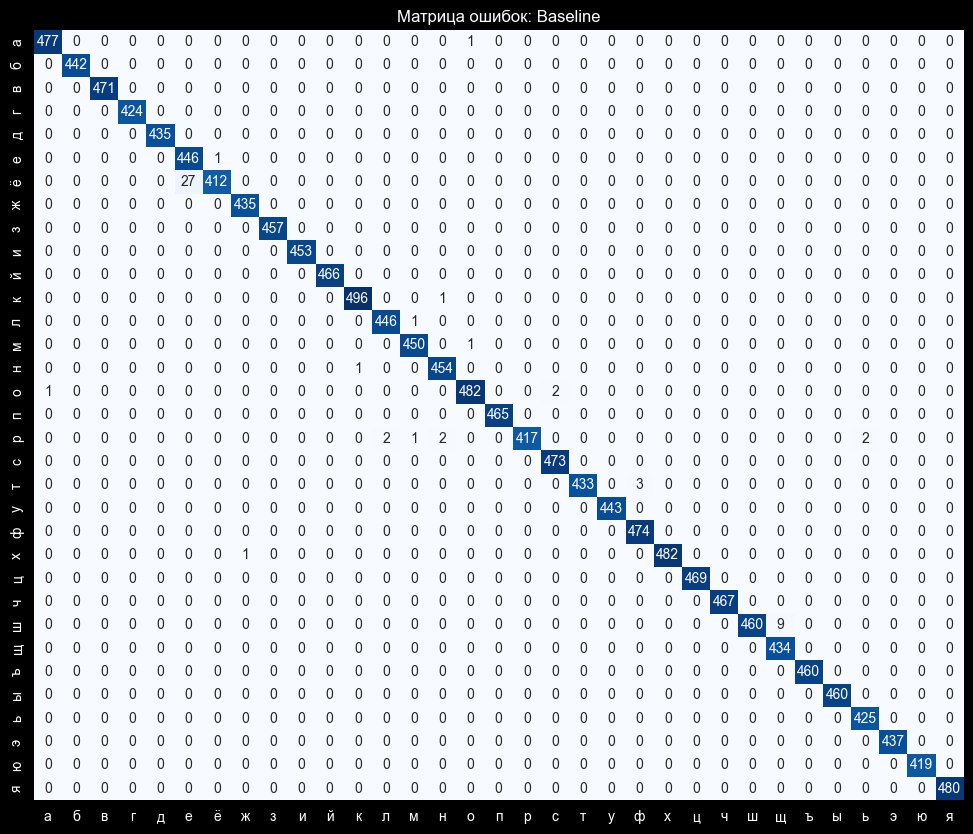

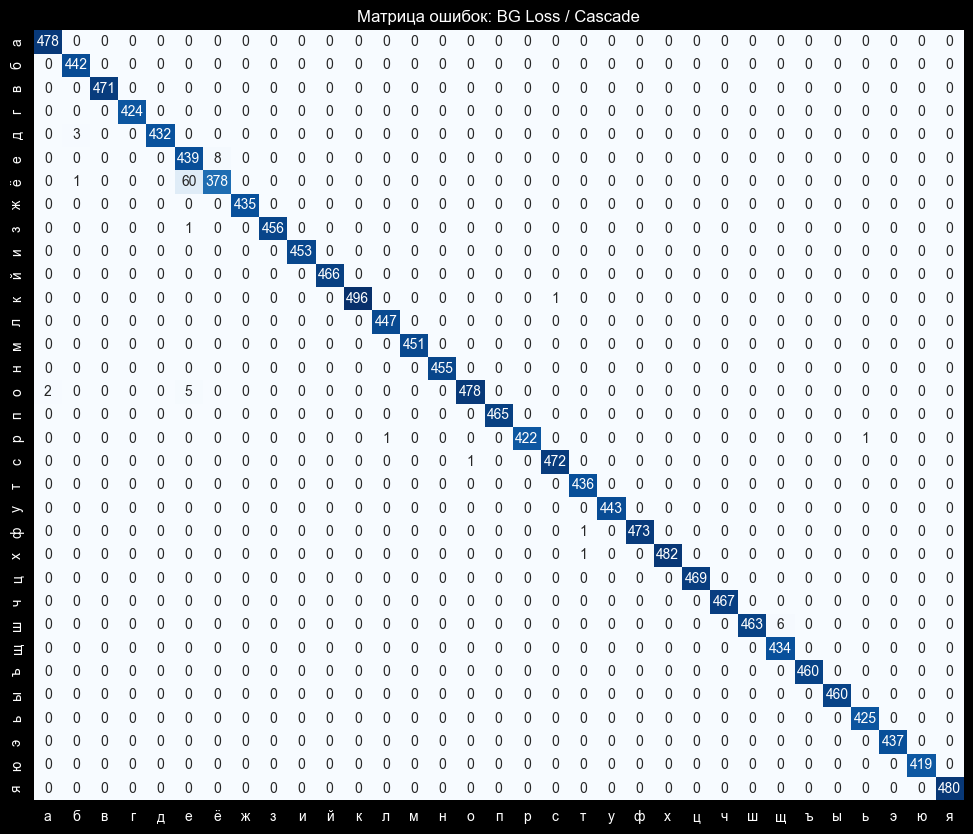

In [8]:
print("\nМатрицы ошибок:")
plot_confusion_matrices(model_base, model_bg, test_loader, test_dataset, device)


Визуализация Classic Grad-CAM (BG Loss Model):


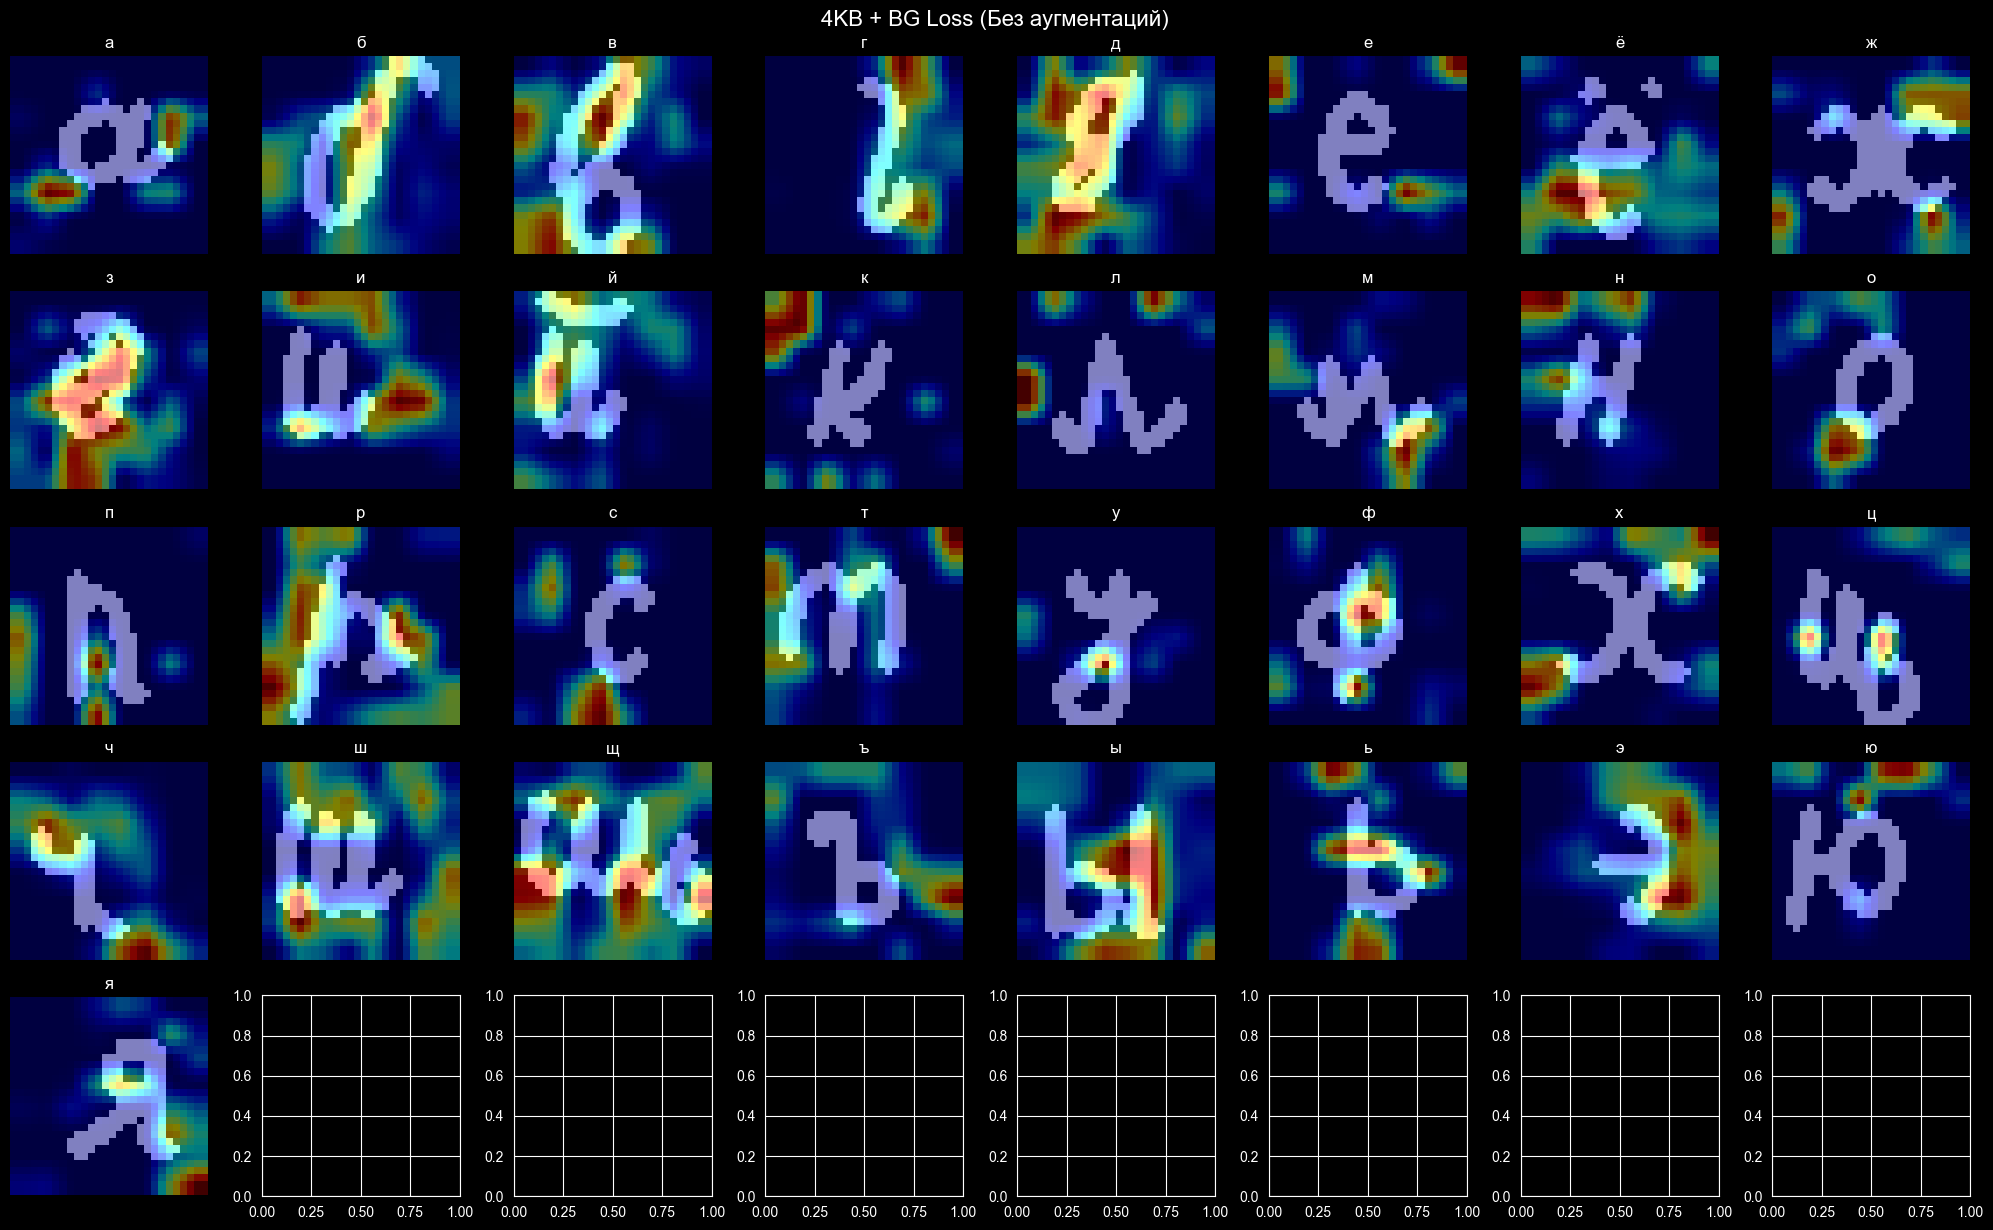

In [9]:
print("\nВизуализация Classic Grad-CAM (BG Loss Model):")
visualize_classic_gradcam(model_bg, test_dataset, device, "4KB + BG Loss (Без аугментаций)")